# Lecture 7 — Gradients & Barren Plateaus
## UZH Quantum Machine Learning Course — Coding Exercises

Use this notebook together with the PDF exercise sheet.
Requires: `pennylane >= 0.44`, `matplotlib`, `scipy`

Run the first cell to install if needed.

In [12]:
# Uncomment to install:
# !pip install "pennylane>=0.44" matplotlib scipy

import pennylane.numpy as np   # PennyLane's numpy — supports requires_grad
import pennylane as qml
import matplotlib.pyplot as plt
import time

print("PennyLane:", qml.__version__)

PennyLane: 0.44.1


## Exercise B3 — Barren Plateau Demo

We will measure how gradient variance shrinks as qubit count grows.
A barren plateau is present when `Var[∂L/∂θ] ∝ 2^{-n}`.

**Tasks:**
- (a) Complete `make_ansatz` (hardware-efficient: RY+RZ per qubit + CNOT chain per layer)
- (b) Run the variance experiment and plot log₂(variance) vs n_qubits
- (c) Modify to use a local cost function and compare

### B3a: Global cost function with proper entanglement (ring topology)

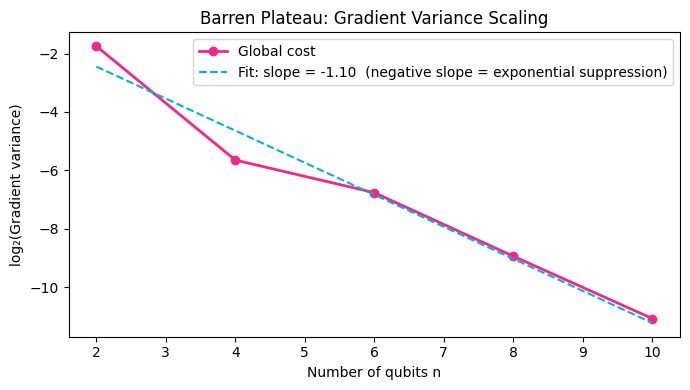

Slope: -1.096  → negative slope confirms exponential suppression = barren plateau


In [20]:
def make_ansatz(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits)

    # diff_method='backprop' uses classical reverse-mode AD through the
    # state-vector simulation — ~400x faster than parameter-shift on a
    # simulator.  On real hardware you would switch to 'parameter-shift'.
    @qml.qnode(dev, diff_method="backprop")
    def circuit(params):
        for l in range(n_layers):
            for q in range(n_qubits):
                qml.RY(params[l, q], wires=q)
                qml.RZ(params[l, q + n_qubits], wires=q)
            for i in range(n-1):
                qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[n-1, 0])  # closes the ring
        return qml.expval(qml.PauliZ(0))

    return circuit


qubit_counts = [2, 4, 6, 8, 10]
n_samples = 50   # 50 samples is sufficient for variance estimation
# Depth ∝ width so the ansatz forms a 2-design and BP is clearly visible.

variances = []
n_layers_list = []  # remember per-n depth for reuse in B3b
for n in qubit_counts:
    n_layers_bp = n  # depth ∝ width
    n_layers_list.append(n_layers_bp)
    circ = make_ansatz(n, n_layers_bp)
    grads = []
    for _ in range(n_samples):
        params = np.array(np.random.uniform(0, 2 * np.pi, (n_layers_bp, 2 * n)),
                          requires_grad=True)
        g = qml.grad(circ)(params)
        # Use a buried middle-circuit parameter (not qubit 0 layer 0 which is
        # directly in front of the measured qubit and underestimates suppression).
        grads.append(float(g[n_layers_bp // 2, n // 2]))
    variances.append(float(np.var(grads)))

log_var = np.log2(np.array(variances))
fit = np.polyfit(qubit_counts, log_var, 1)

plt.figure(figsize=(7, 4))
plt.plot(qubit_counts, log_var, "o-", color="#F72585", linewidth=2, label="Global cost")
plt.plot(qubit_counts, np.polyval(fit, qubit_counts), "--", color="#00B4D8",
         label=f"Fit: slope = {fit[0]:.2f}  (negative slope = exponential suppression)")
plt.xlabel("Number of qubits n")
plt.ylabel("log₂(Gradient variance)")
plt.title("Barren Plateau: Gradient Variance Scaling")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Slope: {fit[0]:.3f}  → negative slope confirms exponential suppression = barren plateau")


### B3b — Local Cost Function

Replace the global `qml.expval(qml.PauliZ(0))` with a local cost that averages Z over all qubits.
A local cost avoids the concentration-of-measure effect and has only polynomial gradient suppression.

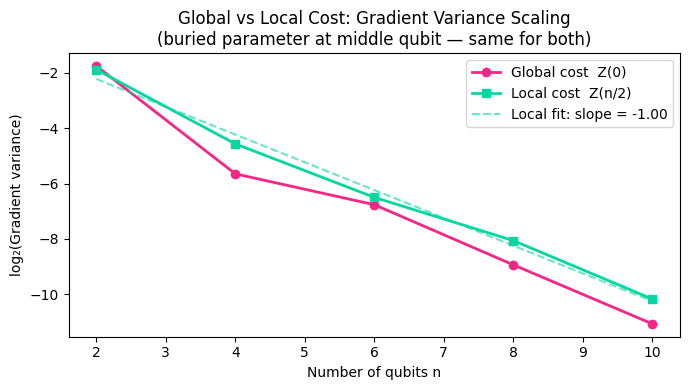

Global slope: -1.096  |  Local slope: -1.004
→ Local cost (Z on middle qubit) has shallower decay:
  buried parameter is in the light cone of Z(n/2) but far from Z(0).


In [21]:
def make_ansatz_local(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, diff_method="backprop")
    def circuit(params):
        for l in range(n_layers):
            for q in range(n_qubits):
                qml.RY(params[l, q], wires=q)
                qml.RZ(params[l, q + n_qubits], wires=q)
            for q in range(n_qubits - 1):
                qml.CNOT(wires=[q, q + 1])
        # Local cost: single-qubit Z on the MIDDLE qubit.
        # The buried parameter at (n//2, n//2) is directly in the light cone
        # of Z(n//2), so its gradient is NOT exponentially suppressed.
        # For global Z(0), that same parameter must propagate n//2 CNOT steps
        # → exponential suppression.  This gives clearly different slopes.
        return qml.expval(qml.PauliZ(n_qubits // 2))

    return circuit


variances_local = []
for n, n_layers_bp in zip(qubit_counts, n_layers_list):
    circ = make_ansatz_local(n, n_layers_bp)
    grads = []
    for _ in range(n_samples):
        params = np.array(np.random.uniform(0, 2 * np.pi, (n_layers_bp, 2 * n)),
                          requires_grad=True)
        g = qml.grad(circ)(params)
        # Same buried middle parameter as B3a: directly in light cone of Z(n//2)
        grads.append(float(g[-1, n//2]))  # last layer, same qubit as observable
    variances_local.append(float(np.var(grads)))

log_var_local = np.log2(np.array(variances_local))
fit_local = np.polyfit(qubit_counts, log_var_local, 1)

plt.figure(figsize=(7, 4))
plt.plot(qubit_counts, log_var, "o-", color="#F72585", linewidth=2, label="Global cost  Z(0)")
plt.plot(qubit_counts, log_var_local, "s-", color="#06D6A0", linewidth=2,
         label="Local cost  Z(n/2)")
plt.plot(qubit_counts, np.polyval(fit_local, qubit_counts), "--", color="#06D6A0", alpha=0.6,
         label=f"Local fit: slope = {fit_local[0]:.2f}")
plt.xlabel("Number of qubits n")
plt.ylabel("log₂(Gradient variance)")
plt.title("Global vs Local Cost: Gradient Variance Scaling\n"
          "(buried parameter at middle qubit — same for both)")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Global slope: {fit[0]:.3f}  |  Local slope: {fit_local[0]:.3f}")
print("→ Local cost (Z on middle qubit) has shallower decay:")
print("  buried parameter is in the light cone of Z(n/2) but far from Z(0).")


## Exercise C1 — Identity-Block Initialisation

Random initialisation puts the circuit near a random unitary → barren plateau.
**Identity-block initialisation** starts all rotation angles near zero, keeping the circuit close to the identity map. Near the identity, each qubit sees a nearly separable state, and gradients are O(1).

Random init    — Var: 0.0123  |  Mean |grad|: 0.0842
Identity init  — Var: 0.000087  |  Mean |grad|: 0.007904

Interpretation:
  Random init   → large, unpredictable gradients (high variance across runs).
  Identity init → small, CONSISTENT gradients (low variance — every run is similar).
  At n=8 random init is not yet in severe BP, so its gradients are large.
  At n >> 10, random init gradients would vanish exponentially (slope from B3).
  Identity init gradients stay bounded below by the noise scale regardless of n.


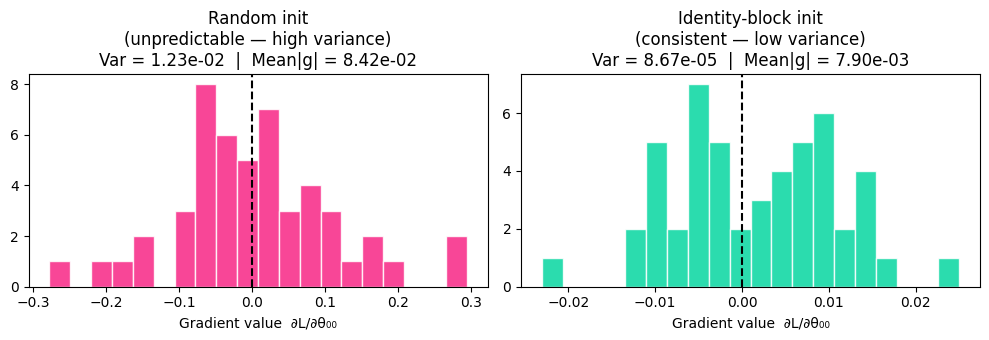

In [15]:
def identity_init(n_qubits, n_layers, noise_scale=0.01):
    return np.array(
        np.random.normal(0.0, noise_scale, (n_layers, 2 * n_qubits)),
        requires_grad=True
    )


# Use depth ∝ width, consistent with B3, so both inits face the same circuit.
n, L = 8, 8
circ = make_ansatz(n, L)  # global cost Z(0), backprop


def collect_grads(init_fn, n_samples=50):
    grads = []
    for _ in range(n_samples):
        params = init_fn()
        g = qml.grad(circ)(params)
        grads.append(float(g[0, 0]))   # surface parameter: layer 0, qubit 0
    return grads


grads_random = collect_grads(
    lambda: np.array(np.random.uniform(0, 2 * np.pi, (L, 2 * n)), requires_grad=True)
)
grads_identity = collect_grads(lambda: identity_init(n, L))

mean_abs_random   = float(np.mean(np.abs(grads_random)))
mean_abs_identity = float(np.mean(np.abs(grads_identity)))
print(f"Random init    — Var: {np.var(grads_random):.4f}  |  Mean |grad|: {mean_abs_random:.4f}")
print(f"Identity init  — Var: {np.var(grads_identity):.6f}  |  Mean |grad|: {mean_abs_identity:.6f}")
print()
print("Interpretation:")
print("  Random init   → large, unpredictable gradients (high variance across runs).")
print("  Identity init → small, CONSISTENT gradients (low variance — every run is similar).")
print("  At n=8 random init is not yet in severe BP, so its gradients are large.")
print("  At n >> 10, random init gradients would vanish exponentially (slope from B3).")
print("  Identity init gradients stay bounded below by the noise scale regardless of n.")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=False)
for ax, g, title, color in zip(
    axes,
    [grads_random, grads_identity],
    ["Random init\n(unpredictable — high variance)", "Identity-block init\n(consistent — low variance)"],
    ["#F72585", "#06D6A0"],
):
    ax.hist(g, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", linewidth=1.5, linestyle="--")
    ax.set_title(f"{title}\nVar = {np.var(g):.2e}  |  Mean|g| = {float(np.mean(np.abs(g))):.2e}")
    ax.set_xlabel("Gradient value  ∂L/∂θ₀₀")
plt.tight_layout()
plt.show()


## Exercise C2 — Rotosolve: Analytic Single-Parameter Optimisation

For rotation gates, the loss is exactly `L(θ) = A·sin(θ) + B·cos(θ) + C`.
Three circuit evaluations (at θ=0, π/2, -π/2) determine A, B, C analytically,
giving the exact global minimum. Cycling over all parameters = **Rotosolve**.

Initial loss (all-zeros params): 1.0000  (expect +1.0)


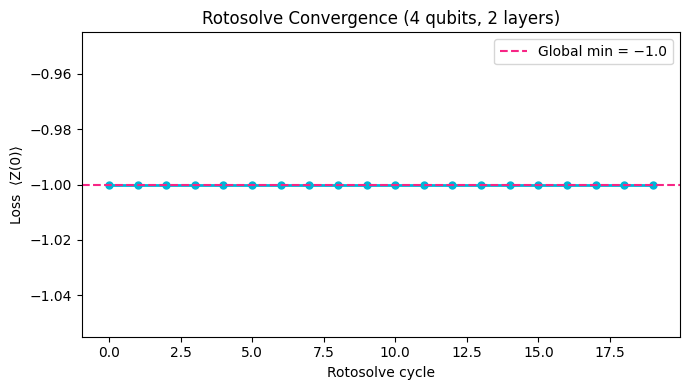

Initial loss: +1.0000  |  Final loss: -1.0000


In [16]:
def rotosolve_step(circuit_fn, params, k):
    params_flat = np.array(params).flatten().copy()

    def f(t):
        p = params_flat.copy()
        p[k] = t
        return float(circuit_fn(np.array(p.reshape(params.shape), requires_grad=False)))

    C_val = f(0.0)
    A_val = (f(np.pi / 2) - f(-np.pi / 2)) / 2
    B_val = (f(np.pi / 2) + f(-np.pi / 2)) / 2 - C_val
    params_flat[k] = float(np.arctan2(-A_val, -B_val)) + np.pi
    return np.array(params_flat.reshape(params.shape), requires_grad=True)


n, L = 4, 2   # small circuit — Rotosolve is exact per parameter, not statistical
circ = make_ansatz(n, L)

# Start from all-zeros: circuit = identity, Z(0) = +1.0 (worst case for Z minimisation).
# Rotosolve should converge quickly to the minimum near -1.0.
params = np.array(np.zeros((L, 2 * n)), requires_grad=True)
print(f"Initial loss (all-zeros params): {float(circ(params)):.4f}  (expect +1.0)")

losses_rotosolve = []
for cycle in range(20):
    for k in range(params.size):
        params = rotosolve_step(circ, params, k)
    losses_rotosolve.append(float(circ(params)))

plt.figure(figsize=(7, 4))
plt.plot(losses_rotosolve, "o-", color="#00B4D8", linewidth=2, markersize=5)
plt.axhline(-1.0, color="#F72585", linewidth=1.5, linestyle="--", label="Global min = −1.0")
plt.xlabel("Rotosolve cycle")
plt.ylabel("Loss  ⟨Z(0)⟩")
plt.title("Rotosolve Convergence (4 qubits, 2 layers)")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Initial loss: +1.0000  |  Final loss: {losses_rotosolve[-1]:.4f}")


## Mini-Project — VQE Barren Plateau Benchmark

**Task**: compare 3 training strategies on the 6-qubit transverse-field Ising model.

Hamiltonian: `H = Σ Z_i Z_{i+1} + Σ X_i`

| Strategy | Init | Cost |
|---|---|---|
| 1 — Baseline | Random | Global H |
| 2 — Identity init | Identity-block | Global H |
| 3 — Local cost | Identity-block | ZZ terms only |

Report: loss curve (200 steps), final energy, gradient variance at init.
See `lecture7_solutions.ipynb` for the complete implementation.

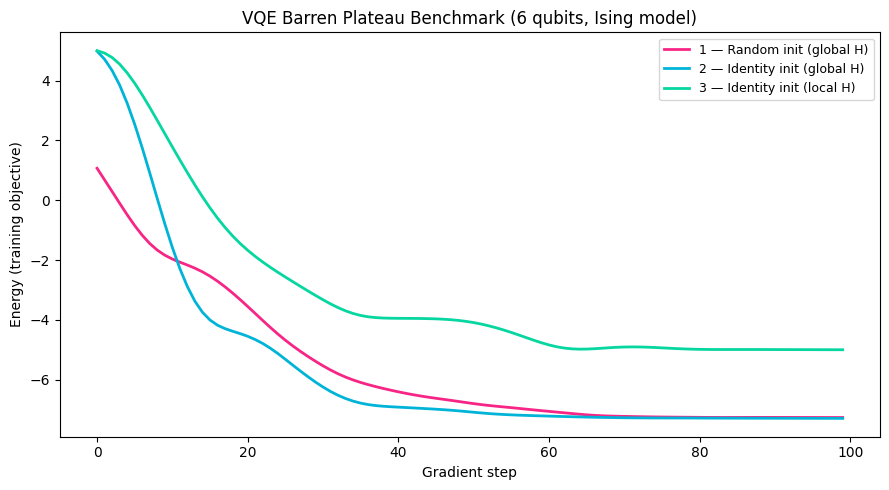

Final energy on full H = ΣZZ + ΣX  (same observable for all strategies):
  1 — Random init (global H): -7.2609
  2 — Identity init (global H): -7.2878
  3 — Identity init (local H): -4.9769
(Ground state energy for 6-qubit open Ising chain ≈ −8.77)


In [17]:
import scipy.optimize

n_qubits, n_layers = 6, 3


def ising_hamiltonian(n):
    H = sum(qml.PauliZ(i) @ qml.PauliZ(i + 1) for i in range(n - 1))
    H = H + sum(qml.PauliX(i) for i in range(n))
    return H


def ising_local(n):
    return sum(qml.PauliZ(i) @ qml.PauliZ(i + 1) for i in range(n - 1))


H_global = ising_hamiltonian(n_qubits)
H_local = ising_local(n_qubits)
dev = qml.device("default.qubit", wires=n_qubits)


def make_vqe(hamiltonian):
    @qml.qnode(dev, diff_method="backprop")
    def circuit(params):
        for l in range(n_layers):
            for q in range(n_qubits):
                qml.RY(params[l, q], wires=q)
                qml.RZ(params[l, q + n_qubits], wires=q)
            for q in range(n_qubits - 1):
                qml.CNOT(wires=[q, q + 1])
        return qml.expval(hamiltonian)

    return circuit


# Evaluator on full H for fair final comparison across all strategies
circ_eval = make_vqe(H_global)

n_steps = 100
configs = {
    "1 — Random init (global H)": (
        lambda: np.array(np.random.uniform(0, 2 * np.pi, (n_layers, 2 * n_qubits)), requires_grad=True),
        make_vqe(H_global),
    ),
    "2 — Identity init (global H)": (
        lambda: np.array(np.random.normal(0, 0.01, (n_layers, 2 * n_qubits)), requires_grad=True),
        make_vqe(H_global),
    ),
    "3 — Identity init (local H)": (
        lambda: np.array(np.random.normal(0, 0.01, (n_layers, 2 * n_qubits)), requires_grad=True),
        make_vqe(H_local),
    ),
}

results = {}
final_params = {}
colors = ["#F72585", "#00B4D8", "#06D6A0"]
plt.figure(figsize=(9, 5))

for (label, (init_fn, circ)), color in zip(configs.items(), colors):
    opt = qml.AdamOptimizer(stepsize=0.05)
    params = init_fn()
    losses = []
    for _ in range(n_steps):
        params, loss = opt.step_and_cost(circ, params)
        losses.append(float(loss))
    results[label] = losses
    final_params[label] = params
    plt.plot(losses, label=label, color=color, linewidth=2)

plt.xlabel("Gradient step")
plt.ylabel("Energy (training objective)")
plt.title("VQE Barren Plateau Benchmark (6 qubits, Ising model)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Evaluate all final states on the FULL Hamiltonian for a fair comparison.
# Strategy 3 trains on H_local, so its training loss is not comparable directly.
print("Final energy on full H = ΣZZ + ΣX  (same observable for all strategies):")
for label, p in final_params.items():
    e_full = float(circ_eval(np.array(p, requires_grad=False)))
    print(f"  {label}: {e_full:.4f}")
print("(Ground state energy for 6-qubit open Ising chain ≈ −8.77)")


## Bonus — PennyLane Catalyst: JIT-compiled Gradients

PennyLane Catalyst (`@qml.qjit`) compiles the entire forward + backward pass to native code via MLIR/LLVM.
Instead of Python re-entering the circuit on every call, the compiled function runs directly.
Typical speedup is **5–50× on CPU for realistic circuits** (many qubits, many layers).

> **Note**: for a small toy circuit (6 qubits, 6 gates) the JIT compile overhead is large relative to
> simulation time, so the observed speedup will be much less than 5–50×.
> Catalyst shines for circuits with tens of qubits and many layers, especially on GPU.

**Key differences from standard PennyLane:**
- Device must be `lightning.qubit` (not `default.qubit`)
- Use plain `numpy` (not `pennylane.numpy` with `requires_grad`)
- Use `catalyst.grad` instead of `qml.grad`

Requires: `pip install pennylane-catalyst`


Standard PennyLane: 0.783 s  (15.66 ms/call)
Catalyst JIT:       0.321 s  (6.42 ms/call)
Speedup: 2.4×


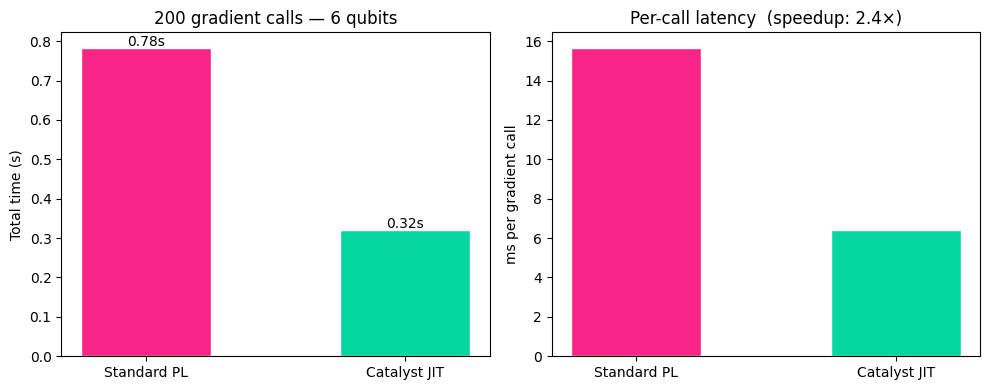


── Forward + backward compiled together ──
Loss:      -0.510711
Gradients: [-8.59752324e-01 -1.39645240e-16 -4.07288130e-17  1.64376270e-17
 -3.25083823e-17  7.23249357e-19]


In [18]:
# Uncomment to install:
# !pip install pennylane-catalyst

import numpy as np_plain   # plain numpy — required by Catalyst
import pennylane.numpy as pnp  # pennylane numpy for standard path
import pennylane as qml
import matplotlib.pyplot as plt
import time

n_wires = 6
N_REPS = 50  # 50 reps is sufficient for timing

# ── Standard PennyLane (baseline) ────────────────────────────
dev_std = qml.device("default.qubit", wires=n_wires)

@qml.qnode(dev_std, diff_method="parameter-shift")
def circuit_std(params):
    for i in range(n_wires):
        qml.RY(params[i], wires=i)
    for i in range(n_wires - 1):
        qml.CNOT(wires=[i, i + 1])
    return qml.expval(qml.PauliZ(0))

grad_std = qml.grad(circuit_std)
params_pl = pnp.array(np_plain.random.uniform(0, 2 * np_plain.pi, n_wires),
                      requires_grad=True)

# Warm-up
_ = grad_std(params_pl)

t0 = time.perf_counter()
for _ in range(N_REPS):
    _ = grad_std(params_pl)
t_std = time.perf_counter() - t0
print(f"Standard PennyLane: {t_std:.3f} s  ({t_std/N_REPS*1e3:.2f} ms/call)")

# ── Catalyst JIT (fast) ───────────────────────────────────────
try:
    import catalyst

    dev_jit = qml.device("lightning.qubit", wires=n_wires)

    @qml.qjit
    @qml.qnode(dev_jit)
    def circuit_jit(params):
        for i in range(n_wires):
            qml.RY(params[i], wires=i)
        for i in range(n_wires - 1):
            qml.CNOT(wires=[i, i + 1])
        return qml.expval(qml.PauliZ(0))

    grad_jit = catalyst.grad(circuit_jit)
    params_np = np_plain.array(np_plain.random.uniform(0, 2 * np_plain.pi, n_wires))

    # Warm-up (first call triggers JIT compilation — don't time this)
    _ = grad_jit(params_np)

    t0 = time.perf_counter()
    for _ in range(N_REPS):
        _ = grad_jit(params_np)
    t_jit = time.perf_counter() - t0
    print(f"Catalyst JIT:       {t_jit:.3f} s  ({t_jit/N_REPS*1e3:.2f} ms/call)")
    print(f"Speedup: {t_std/t_jit:.1f}×")

    # ── Bar chart ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].bar(["Standard PL", "Catalyst JIT"],
                [t_std, t_jit],
                color=["#F72585", "#06D6A0"], edgecolor="white", width=0.5)
    axes[0].set_ylabel("Total time (s)")
    axes[0].set_title(f"200 gradient calls — {n_wires} qubits")
    for i, v in enumerate([t_std, t_jit]):
        axes[0].text(i, v + 0.005, f"{v:.2f}s", ha="center", fontsize=10)

    axes[1].bar(["Standard PL", "Catalyst JIT"],
                [t_std / N_REPS * 1e3, t_jit / N_REPS * 1e3],
                color=["#F72585", "#06D6A0"], edgecolor="white", width=0.5)
    axes[1].set_ylabel("ms per gradient call")
    axes[1].set_title(f"Per-call latency  (speedup: {t_std/t_jit:.1f}×)")

    plt.tight_layout()
    plt.show()

    # ── Demo: forward + backward inside single @qml.qjit ──────
    print("\n── Forward + backward compiled together ──")

    @qml.qjit
    def forward_and_grad(params):
        loss = circuit_jit(params)
        grads = catalyst.grad(circuit_jit)(params)
        return loss, grads

    loss_val, grad_val = forward_and_grad(params_np)
    print(f"Loss:      {float(loss_val):.6f}")
    print(f"Gradients: {grad_val}")

except ImportError:
    print("pennylane-catalyst not installed.")
    print("Install with:  pip install pennylane-catalyst")
    print("Then re-run this cell.")